In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv


In [3]:
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
df = pd.read_csv(os.path.join(path, "weatherAUS.csv"))

df = df.dropna(subset=['RainTomorrow'])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

print(df.head())
print(f"Размер: {df.shape}")

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6     5.469824  7.624853   
1  2008-12-02   Albury      7.4     25.1       0.0     5.469824  7.624853   
2  2008-12-03   Albury     12.9     25.7       0.0     5.469824  7.624853   
3  2008-12-04   Albury      9.2     28.0       0.0     5.469824  7.624853   
4  2008-12-05   Albury     17.5     32.3       1.0     5.469824  7.624853   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 142193 entries, 0 to 145458
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           142193 non-null  object 
 1   Location       142193 non-null  object 
 2   MinTemp        142193 non-null  float64
 3   MaxTemp        142193 non-null  float64
 4   Rainfall       142193 non-null  float64
 5   Evaporation    142193 non-null  float64
 6   Sunshine       142193 non-null  float64
 7   WindGustDir    132863 non-null  object 
 8   WindGustSpeed  142193 non-null  float64
 9   WindDir9am     132180 non-null  object 
 10  WindDir3pm     138415 non-null  object 
 11  WindSpeed9am   142193 non-null  float64
 12  WindSpeed3pm   142193 non-null  float64
 13  Humidity9am    142193 non-null  float64
 14  Humidity3pm    142193 non-null  float64
 15  Pressure9am    142193 non-null  float64
 16  Pressure3pm    142193 non-null  float64
 17  Cloud9am       142193 non-null  fl

In [4]:
df.columns.tolist()

['Date',
 'Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'RainTomorrow']

In [5]:
df.describe().round(2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.00,142193.0,142193.00,142193.00
mean,12.19,23.23,2.35,5.47,7.62,39.98,14.00,18.64,68.84,51.48,1017.65,1015.26,4.44,4.5,16.99,21.69
std,6.39,7.11,8.42,3.17,2.73,13.14,8.85,8.72,18.93,20.53,6.75,6.68,2.28,2.1,6.47,6.87
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.0,-7.20,-5.40
25%,7.60,17.90,0.00,4.00,7.62,31.00,7.00,13.00,57.00,37.00,1013.50,1011.00,3.00,4.0,12.30,16.70
50%,12.00,22.70,0.00,5.47,7.62,39.00,13.00,18.64,70.00,51.48,1017.65,1015.26,4.44,4.5,16.80,21.30
75%,16.80,28.20,0.80,5.47,8.70,46.00,19.00,24.00,83.00,65.00,1021.80,1019.40,6.00,6.0,21.50,26.30
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.0,40.20,46.70


In [4]:
feature_cols = [
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity3pm',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm']

X_raw = df[feature_cols].copy()
X_transformed = X_raw.copy()
#Логарифм осадки сжимает, 
#так как несмотря на то, что это выброс, это не ошибка
#Важно,чтобы это засчитывалось,иначе модель подумает, что ураганов не бывает
X_transformed['Rainfall'] = np.log1p(X_transformed['Rainfall'].fillna(X_transformed['Rainfall'].median()))
X_transformed['Evaporation'] = np.log1p(X_transformed['Evaporation'].fillna(X_transformed['Evaporation'].median()))
#Экстремальные единичные странные выбросы ветра приравнять к максимальному из
#распространённых значений
limit_9am = X_transformed['WindSpeed9am'].quantile(0.99)
X_transformed['WindSpeed9am'] = X_transformed['WindSpeed9am'].clip(upper=limit_9am)

limit_3pm = X_transformed['WindSpeed3pm'].quantile(0.99)
X_transformed['WindSpeed3pm'] = X_transformed['WindSpeed3pm'].clip(upper=limit_3pm)


Text(0.5, 1.0, 'Доли классов')

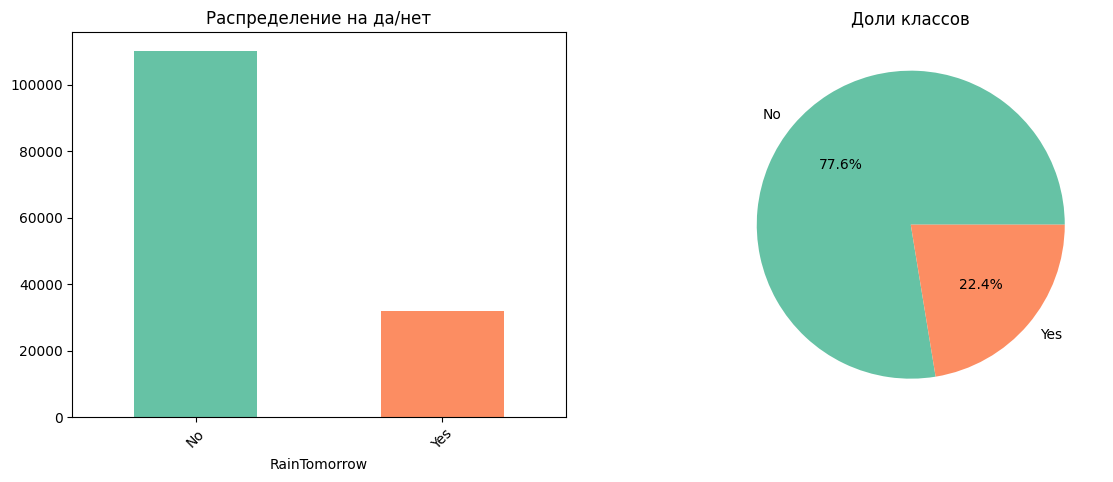

In [5]:
target_col = "RainTomorrow"
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title("Распределение на да/нет")
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')


Заметен дисбаланс классов.

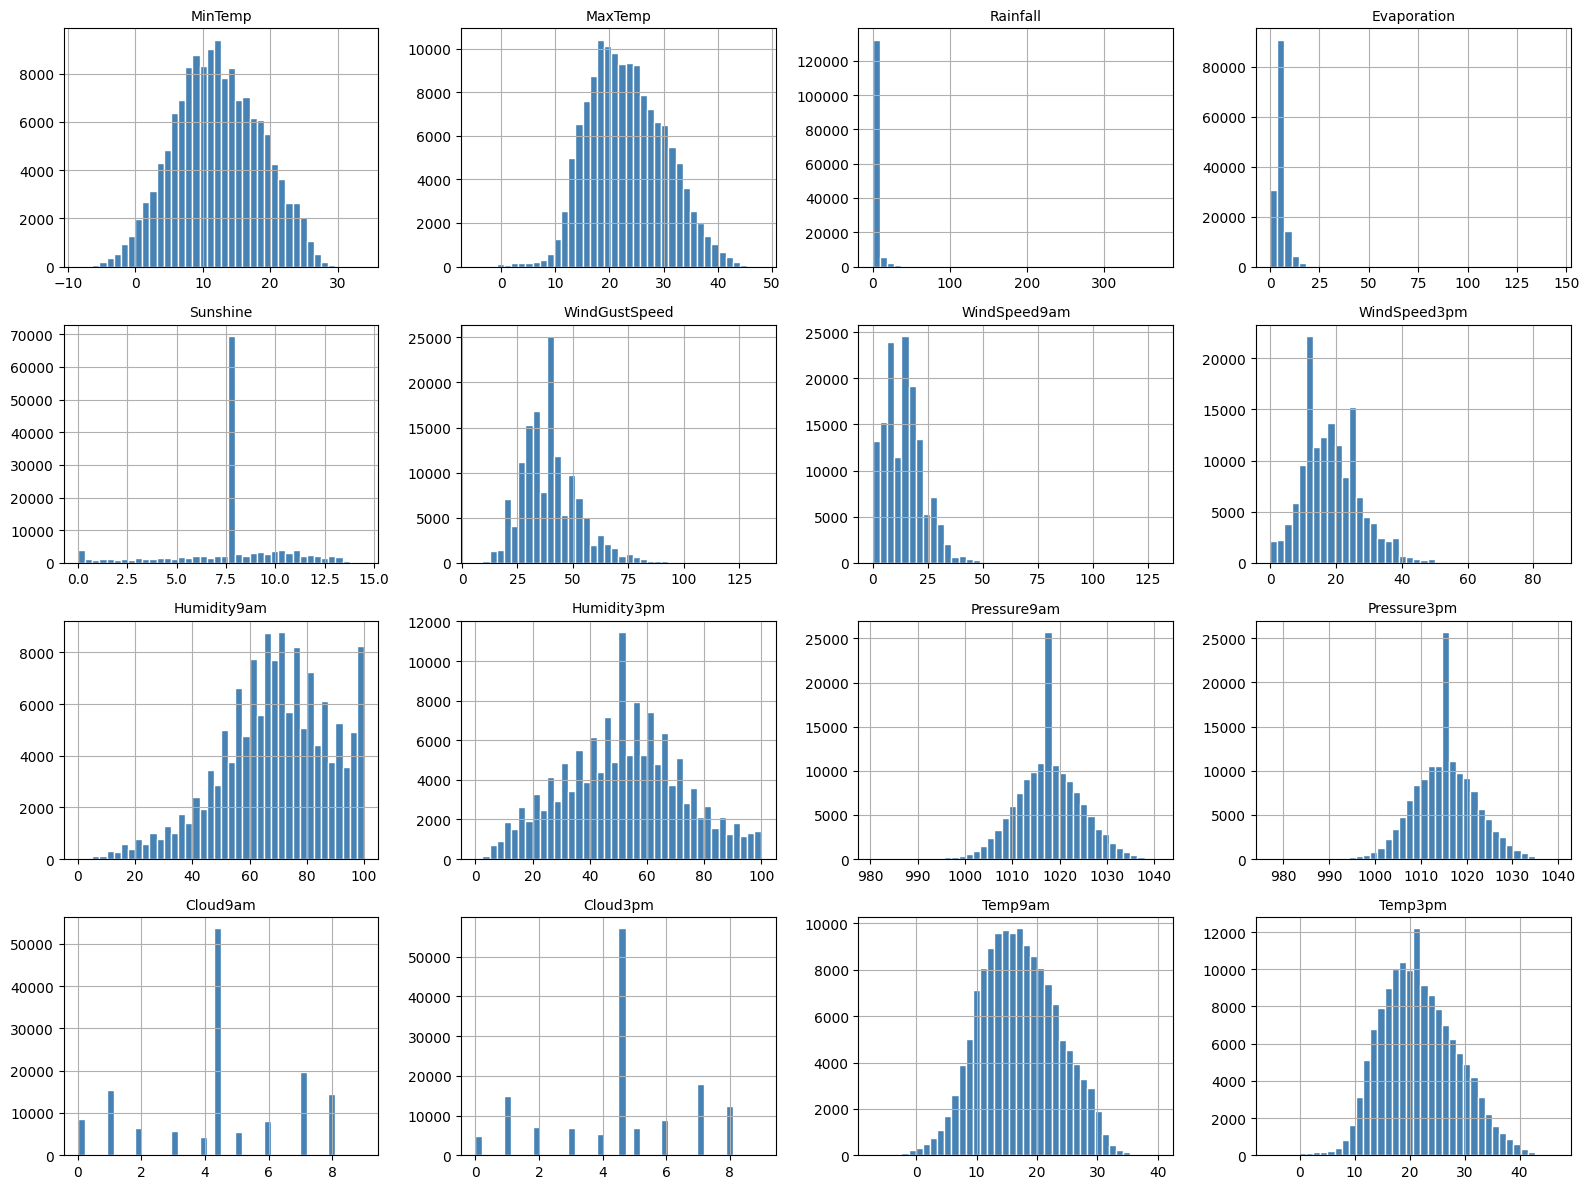

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

На графике заметны выбросы.

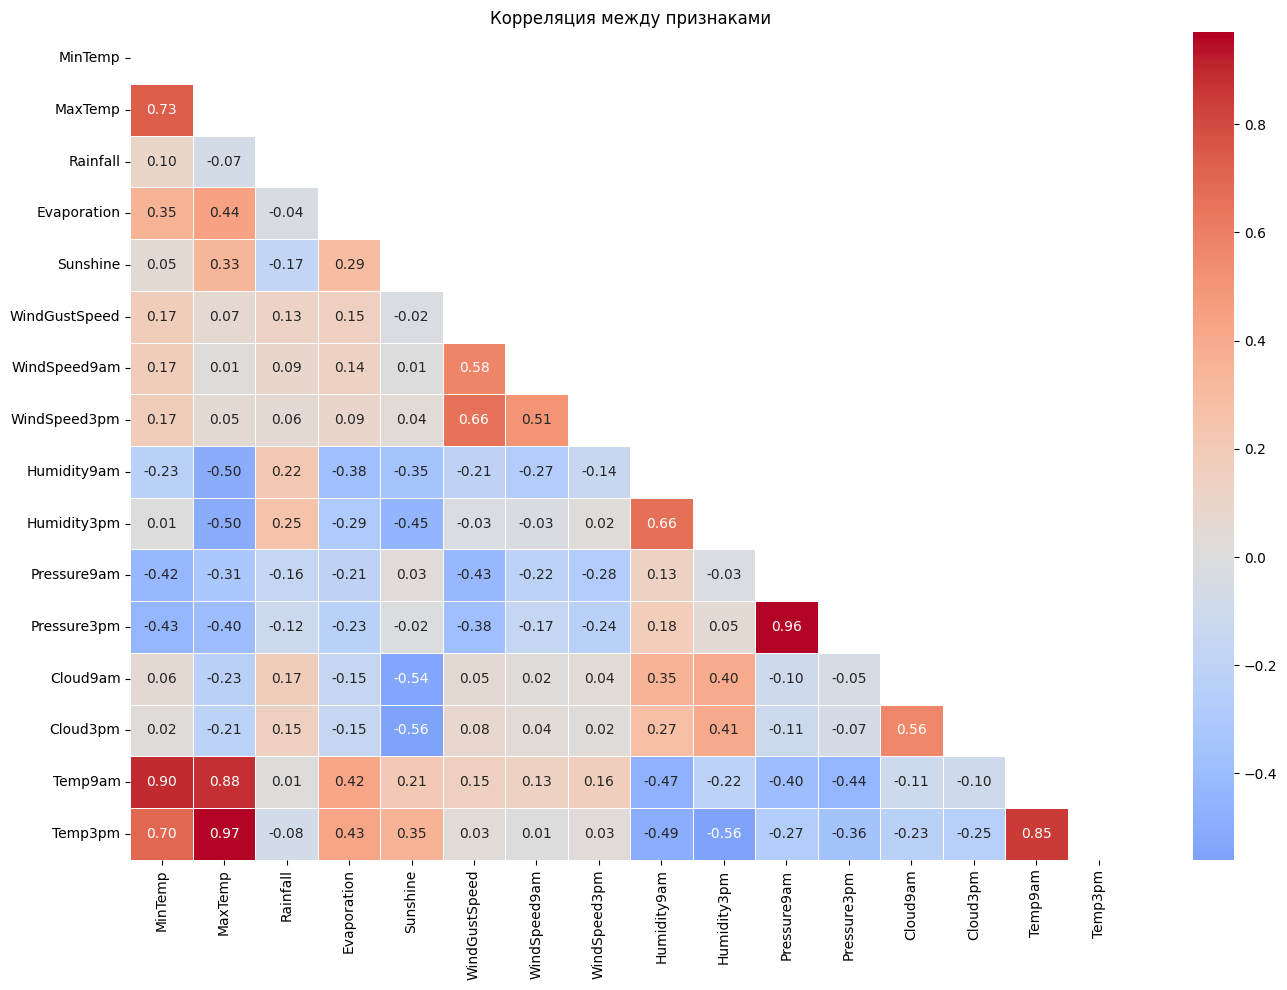

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

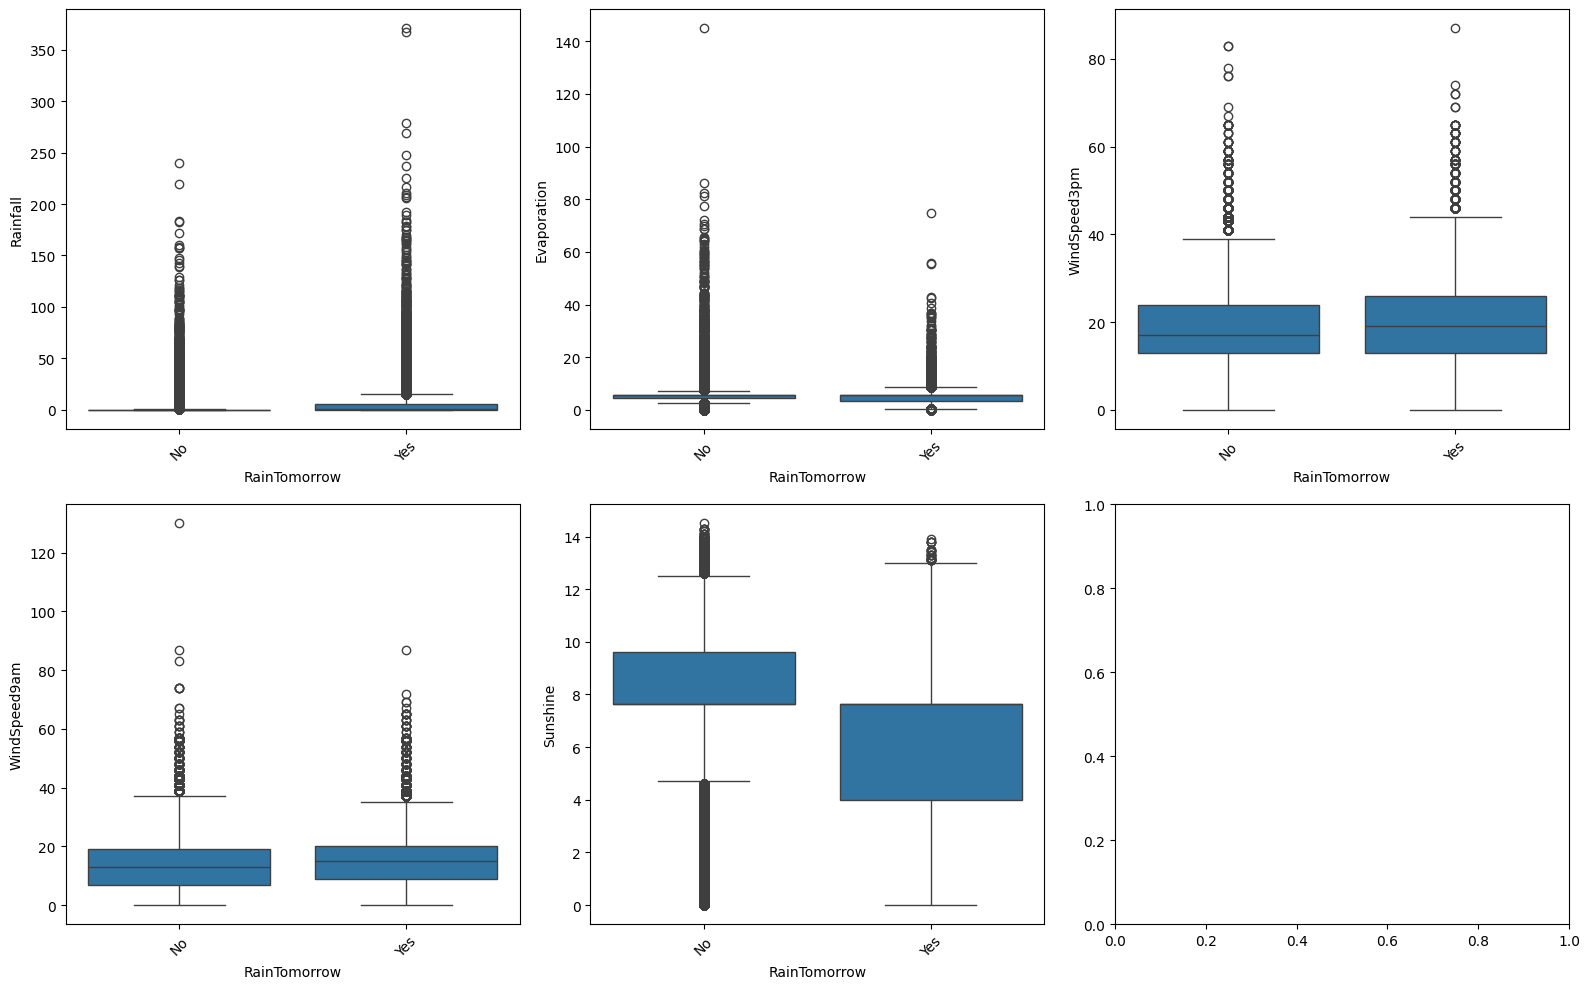

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
top_features = ['Rainfall', 'Evaporation', 'WindSpeed3pm','WindSpeed9am', 'Sunshine']
for idx, col in enumerate(top_features):
    ax = axes[idx // 3][idx % 3]
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

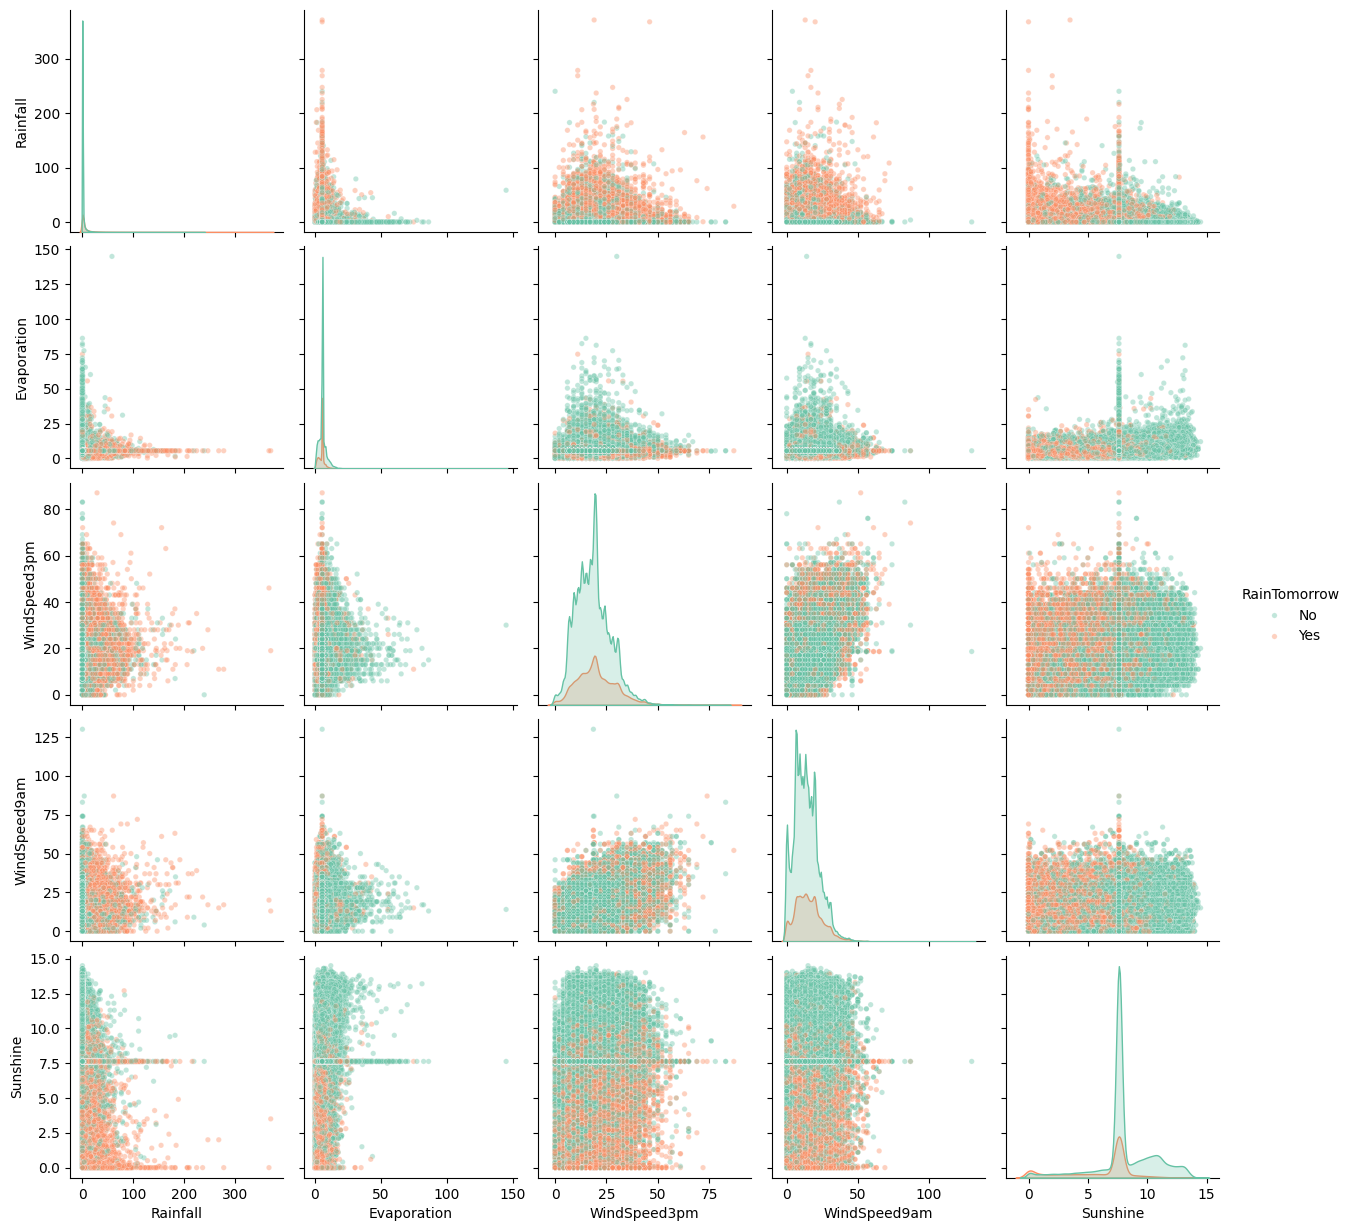

In [27]:
sns.pairplot(df[['Rainfall', 'Evaporation', 'WindSpeed3pm','WindSpeed9am', 'Sunshine', target_col]],
             hue=target_col, palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
plt.show()

Чем выше Sunshine, тем сильнее No у RainTomorrow
При средних значениях ветра сильнее No у дождя
Прослеживается прямая линейная связь между утренней и дневной скоростью ветра (`WindSpeed9am` и `WindSpeed3pm`).

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

y = df['RainTomorrow'].map({'Yes': 1, 'No': 0}).values

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y, test_size=0.2, random_state=123, stratify=y
)

X_train_trans, X_test_trans, y_train_trans, y_test_trans = train_test_split(
    X_transformed, y, test_size=0.2, random_state=123, stratify=y
)


In [7]:
# Проверяем распределение классов (сколько 0 и 1)
print(pd.Series(y).value_counts(normalize=True))

0    0.775819
1    0.224181
Name: proportion, dtype: float64


In [8]:
print(f"Всего NaN в данных: {X_train_trans.isna().sum().sum()}")
print(f"Количество строк с NaN: {X_train_trans.isna().any(axis=1).sum()}")
print(f"Количество столбцов с NaN: {X_train_trans.isna().any(axis=0).sum()}")

# Количество NaN по каждому столбцу
nan_counts = X_train_trans.isna().sum()
print("\nNaN по столбцам:")
print(nan_counts[nan_counts > 0])

Всего NaN в данных: 0
Количество строк с NaN: 0
Количество столбцов с NaN: 0

NaN по столбцам:
Series([], dtype: int64)


# Гипотеза 1 :  Удаление выбросов улучшит F1-score модели

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('select', SelectKBest(score_func=f_classif)),
    ('logreg', LogisticRegression(class_weight='balanced', random_state=123))
])

param_grid = {
    'select__k': [5, 10, 12, 'all'],           
    'logreg__C': [0.01, 0.1, 1.0, 10.0]        
}

grid_raw = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_raw.fit(X_train_raw, y_train_raw)

grid_trans = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_trans.fit(X_train_trans, y_train_trans)

score_raw = cross_val_score(pipe, X_train_raw, y_train_raw, cv=cv, scoring='f1_macro')
score_trans = cross_val_score(pipe, X_train_trans, y_train_trans, cv=cv, scoring='f1_macro')

if score_trans.mean() > score_raw.mean():
    print('Подтверилось', score_trans, ' ', score_raw)
else:
    print('Не подтверилось', score_trans, ' ', score_raw)

Подтверилось [0.72723503 0.73338547 0.73088903 0.73103492 0.73086237]   [0.7240919  0.73317977 0.72961373 0.72741913 0.72934854]


#  Гипотеза 2 : Recall покажет картину работы модели лучше, чем Accuracy, т.к. у нас дисбаланс классов

In [13]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, classification_report

pipe.fit(X_train_trans, y_train_trans)
y_pred = pipe.predict(X_test_trans)

acc = accuracy_score(y_test_trans, y_pred)
rec_macro = recall_score(y_test_trans, y_pred, average='macro')

if acc < rec_macro:
    print("Подтверждение: ", acc, " ", rec_macro)
else:
    print("Опровержение: ", acc, " ", rec_macro)

Опровержение:  0.7842047891979325   0.7772164967509847


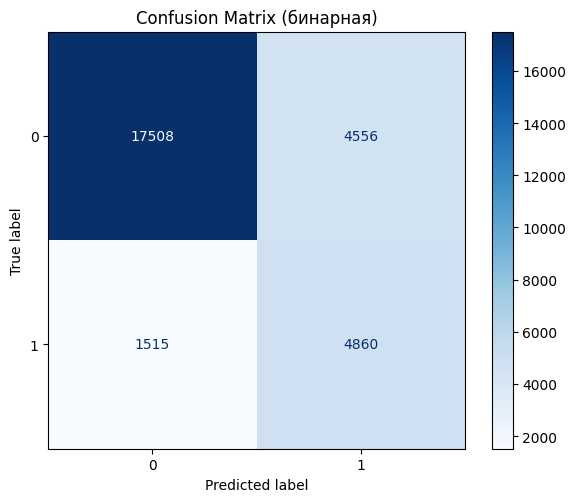

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_trans, y_pred, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix (бинарная)')
plt.tight_layout()
plt.show()

In [21]:
pd.DataFrame({
    'Accuracy': [accuracy_score(y_test_trans, y_pred)],
    'Precision': [precision_score(y_test_trans, y_pred)],
    'Recall': [recall_score(y_test_trans, y_pred)],
    'F1': [f1_score(y_test_trans, y_pred)],
    'F1_macro': [f1_score(y_test_trans, y_pred, average='macro')],
}, index=['LogReg (binary)']).round(4)

,Accuracy,Precision,Recall,F1,F1_macro
LogReg (binary),0.7865,0.5161,0.7624,0.6155,0.7339


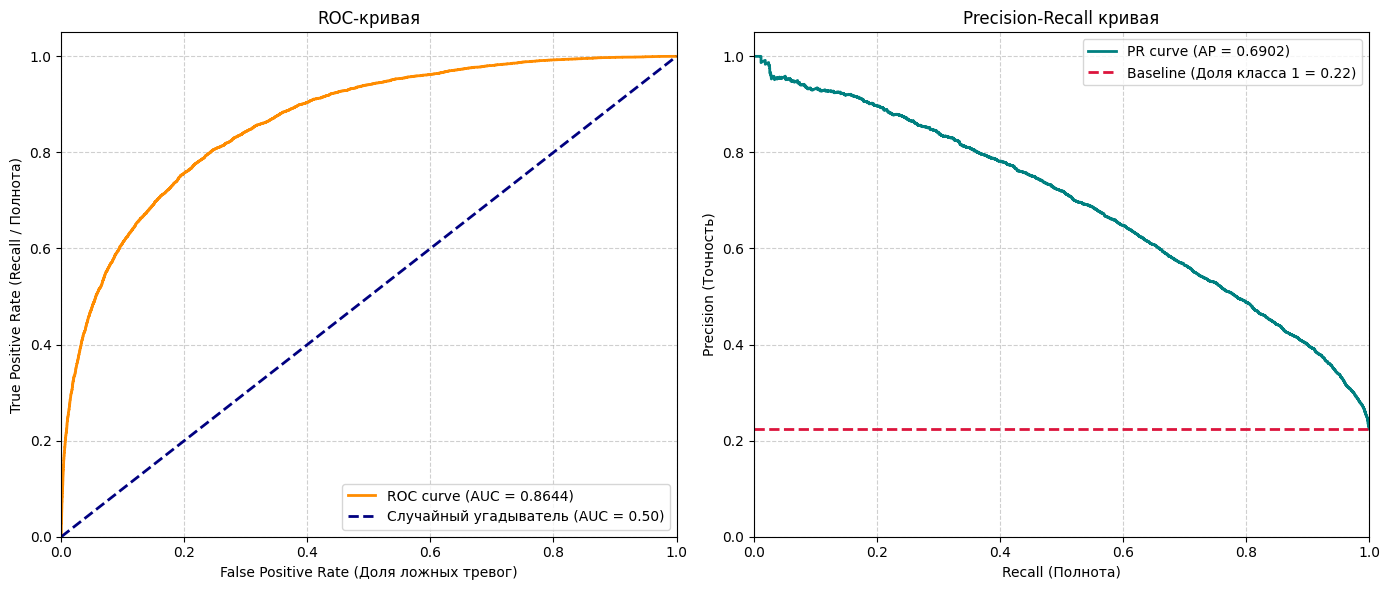

ROC-AUC: 0.8644
PR-AUC (Average Precision): 0.6902


In [22]:
from sklearn.metrics import (
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

# 1. Получаем предсказанные вероятности для класса "Дождь (1)"
y_proba = pipe.predict_proba(X_test_trans)[:, 1]

# 2. Расчет метрик ROC
fpr, tpr, _ = roc_curve(y_test_trans, y_proba)
roc_auc_val = auc(fpr, tpr)

# 3. Расчет метрик Precision-Recall
precision, recall, _ = precision_recall_curve(y_test_trans, y_proba)
pr_auc_val = average_precision_score(y_test_trans, y_proba)

# 4. Построение графиков
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- График 1: ROC-кривая ---
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Случайный угадыватель (AUC = 0.50)')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (Доля ложных тревог)')
axes[0].set_ylabel('True Positive Rate (Recall / Полнота)')
axes[0].set_title('ROC-кривая')
axes[0].legend(loc="lower right")
axes[0].grid(True, linestyle='--', alpha=0.6)

# --- График 2: Precision-Recall кривая ---
baseline_pr = y_test_trans.sum() / len(y_test_trans) # Доля дождливых дней в датасете
axes[1].plot(recall, precision, color='teal', lw=2, label=f'PR curve (AP = {pr_auc_val:.4f})')
axes[1].axhline(y=baseline_pr, color='crimson', lw=2, linestyle='--', label=f'Baseline (Доля класса 1 = {baseline_pr:.2f})')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall (Полнота)')
axes[1].set_ylabel('Precision (Точность)')
axes[1].set_title('Precision-Recall кривая')
axes[1].legend(loc="upper right")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_val:.4f}")
print(f"PR-AUC (Average Precision): {pr_auc_val:.4f}")

# Гипотеза 3 : При глубине дерева < 6 будет underfitting 

# Гипотеза 4 : Дерево решений покажет более высокий F1-score, чем логистическая регрессия, потому что есть нелинейные признаки

(обе ниже)

In [23]:
from sklearn.tree import DecisionTreeClassifier
des_tree = DecisionTreeClassifier(max_depth=9, class_weight='balanced', random_state=123)
des_tree.fit(X_train_trans, y_train_trans)

y_predTree = des_tree.predict(X_test_trans)

f1_rain = f1_score(y_test_trans, y_predTree, pos_label=1)
f1_macro = f1_score(y_test_trans, y_predTree, average='macro')

print(f1_rain, f1_macro)

0.6068010075566751 0.7272504476780399


для глубины 6 : 0.6054674756964833 0.729967739436651 

для глубины 3 : 0.5632154006243496 0.7006959370236585

для глубины 9 : 0.6068010075566751 0.7272504476780399

лог регрессия : 0.6155	0.7339 

Гипотеза про underfitting подтверждена 

Гипотеза про лучший F1 у дерева по сравнению с лог регрессией опровергнута

# Гипотеза 5 : Обучение модели только на признаках, измеренных в 15:00 (3pm), даст качество (F1-score) почти не уступающее модели на всех признаках сразу

In [29]:
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('LogisticRegression', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=123))
])

cols_3pm = [col for col in X_train_trans.columns if '3pm' in col.lower()]

score_3pm = cross_val_score(pipe, X_train_trans[cols_3pm], y_train_trans, cv=cv, scoring='f1_macro').mean()

print(f"F1-macro (Все признаки): 0.7339")
print(f"F1-macro (Только 3pm):   {score_3pm:.4f}")

F1-macro (Все признаки): 0.7339
F1-macro (Только 3pm):   0.7049


In [ ]:
Гипотеза подтвердилась.
Использование только признаков в 3 часа дня незначительно ухудшило результаты